In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

import os
import tensorflow as tf
import keras
import cv2
import glob
import seaborn as sns
import random

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import layers , models, optimizers


# **Data Geneartor**

In [2]:
# specifing new image shape for resnet
img_shape = 224
batch_size = 64
test_data_path = './test/'

In [3]:
test_preprocessor = ImageDataGenerator(
    rescale = 1 / 255.,
)

test_data = test_preprocessor.flow_from_directory(
    test_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size,
)

Found 7178 images belonging to 7 classes.


In [4]:
# Loading the best model
ResNet50V2_Model = models.load_model("ResNet50V2_Model.h5")

# **Evaluating ResNet50V2**

In [5]:
ResNet50V2_Score = ResNet50V2_Model.evaluate(test_data)

print("    Test Loss: {:.5f}".format(ResNet50V2_Score[0]))
print("Test Accuracy: {:.2f}%".format(ResNet50V2_Score[1] * 100))

113/113 [==============================] - 111s 979ms/step - loss: 0.9179 - accuracy: 0.6818
    Test Loss: 0.91790
Test Accuracy: 68.18%


### **Predictions**

In [6]:
# Predictions
ResNet50V2_Predictions = ResNet50V2_Model.predict(test_data)

# Choosing highest probalbilty class in every prediction 
ResNet50V2_Predictions = np.argmax(ResNet50V2_Predictions, axis=1)

113/113 [==============================] - 112s 988ms/step


### **Confusion Matrix**

In [39]:
cm

array([[ 614,   15,   80,   28,   78,  124,   19],
       [  39,   53,    5,    3,    2,    8,    1],
       [ 125,    5,  466,   28,  100,  219,   81],
       [  29,    0,   22, 1566,   85,   35,   37],
       [  61,    3,   57,   75,  855,  168,   14],
       [ 116,    3,  147,   54,  218,  696,   13],
       [  25,    1,   85,   32,   33,   11,  644]])

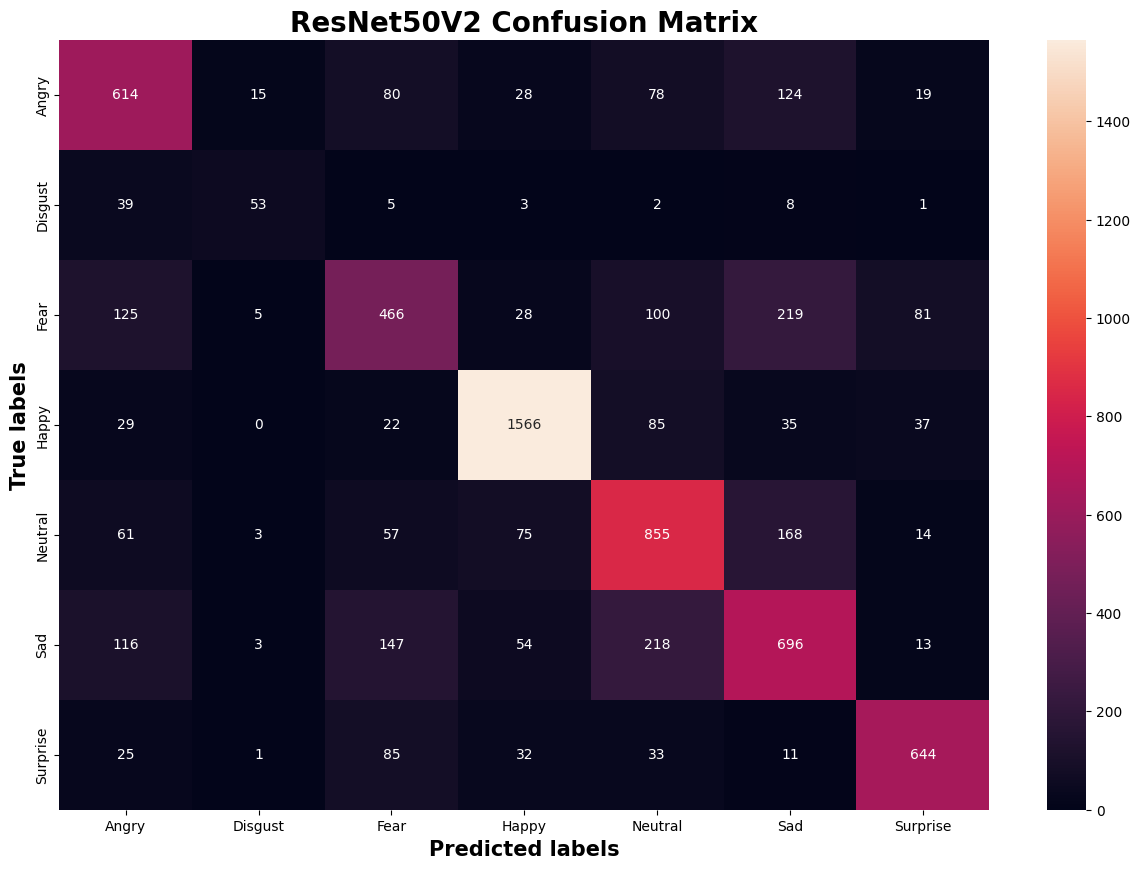

              precision    recall  f1-score   support

       Angry       0.61      0.64      0.62       958
     Disgust       0.66      0.48      0.55       111
        Fear       0.54      0.46      0.49      1024
       Happy       0.88      0.88      0.88      1774
     Neutral       0.62      0.69      0.66      1233
         Sad       0.55      0.56      0.56      1247
    Surprise       0.80      0.77      0.79       831

    accuracy                           0.68      7178
   macro avg       0.67      0.64      0.65      7178
weighted avg       0.68      0.68      0.68      7178



In [7]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Confusion matrix
cm = confusion_matrix(test_data.labels, ResNet50V2_Predictions)

# Plot the confusion matrix as a heatmap
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='g', ax=ax, xticklabels=emotion_labels, yticklabels=emotion_labels)
ax.set_xlabel('Predicted labels', fontsize=15, fontweight='bold')
ax.set_ylabel('True labels', fontsize=15, fontweight='bold')
ax.set_title('ResNet50V2 Confusion Matrix', fontsize=20, fontweight='bold')
plt.show()

# Generate and print the classification report
print(classification_report(test_data.labels, ResNet50V2_Predictions, target_names=emotion_labels))

# **Visualizing Predictions**

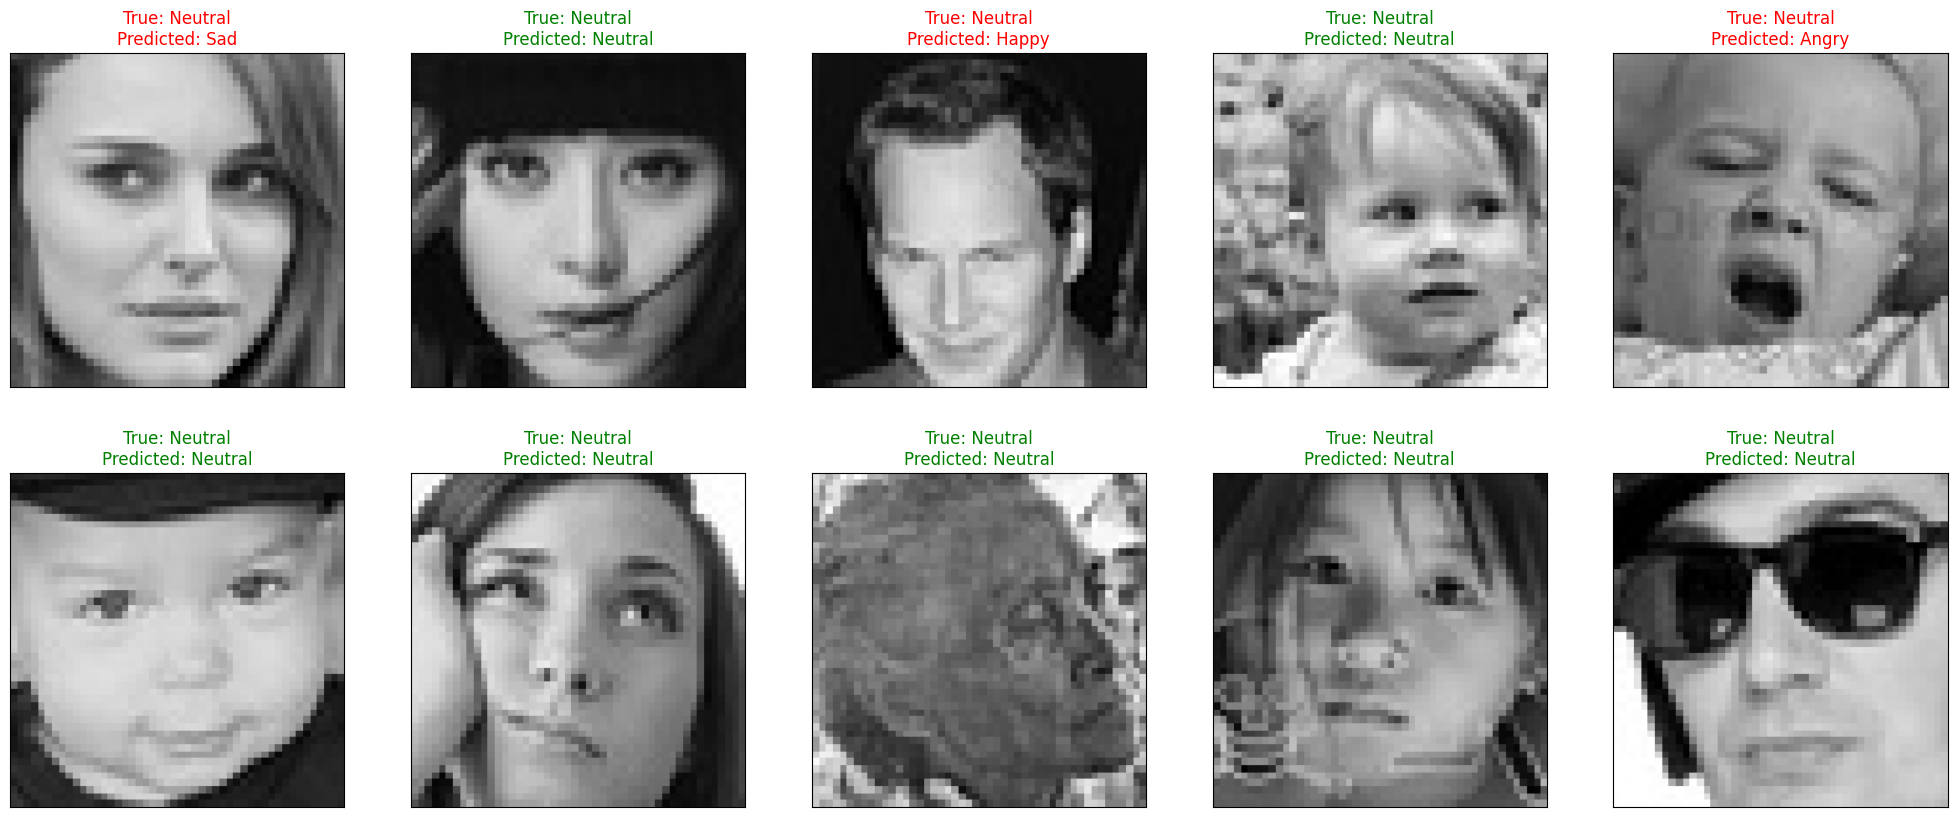

<Figure size 640x480 with 0 Axes>

In [38]:
# Display 10 random pictures from the dataset with their labels

random_batch = np.random.randint(0, len(test_data) - 1)
random_img_id = random.sample(range(batch_size - 1), 10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    random_img = test_data[random_batch][0][random_img_id[i]]
    img_label = np.argmax(test_data[random_batch][1][random_img_id[i]])
    prediction = np.argmax(ResNet50V2_Model.predict( tf.expand_dims(random_img, axis=0) , verbose=0))

    ax.imshow(random_img)

    if emotion_labels[img_label] == emotion_labels[prediction]:
          color = "green"
    else:
          color = "red"
        
    ax.set_title(f"True: {emotion_labels[img_label]}\nPredicted: {emotion_labels[prediction]}", color=color)
plt.show()
plt.tight_layout()